# NB0.1: Participant Demographics
- **Purpose:** Provide a descriptive overview of the participant cohort.
- **Cohort:** Completers only ($N=51$ by default, controlled by `helpers.FILTER_COMPLETERS`).
- **Fields:** Age, Gender, School, Residence, Experience, Healthcare background, and Treatment Group balance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
sys.path.append(os.path.abspath("."))
import helpers

import warnings
warnings.filterwarnings("ignore")

# 1. Load Data
df_recruitment = helpers.load_data(filter_completers=False)
df_analysis = helpers.load_data(filter_completers=True)

df_part_rec = helpers.participant_summary(df_recruitment)
df_part_ana = helpers.participant_summary(df_analysis)

print(f"Total Recruited Cohort: N={len(df_part_rec)}")
print(f"Final Analysis Cohort: N={len(df_part_ana)}")

# Use analysis cohort for specific breakdowns below
df_part = df_part_ana


Data Loading: 68 participants selected (from 68 initial).
Data Loading: 51 participants selected (from 68 initial).
Total Recruited Cohort: N=68
Final Analysis Cohort: N=51


## Section 1: Summary Statistics
A high-level view of the cohort's basic demographics.

In [2]:
def print_value_counts(df, col):
    if col not in df.columns:
        print(f"\n--- {col.upper()} (Missing from DataFrame) ---")
        return
    counts = df[col].value_counts()
    pcts = df[col].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'Count': counts, 'Percentage': pcts.round(1)})
    print(f"\n--- {col.upper()} ---")
    print(summary)

print(f"Age Range: {df_part['age'].min()} - {df_part['age'].max()} (Mean: {df_part['age'].mean():.2f}, SD: {df_part['age'].std():.2f})")
print_value_counts(df_part, 'gender')
print_value_counts(df_part, 'school')
print_value_counts(df_part, 'residence')
print_value_counts(df_part, 'experience_level')
print_value_counts(df_part, 'healthcare_qualification')
print_value_counts(df_part, 'treatment_group')

Age Range: 15 - 18 (Mean: 16.41, SD: 0.67)

--- GENDER ---
        Count  Percentage
gender                   
male       27        52.9
female     24        47.1

--- SCHOOL ---
           Count  Percentage
school                      
secondary     46        90.2
primary        5         9.8

--- RESIDENCE ---
           Count  Percentage
residence                   
budapest      36        70.6
city          10        19.6
village        5         9.8

--- EXPERIENCE_LEVEL ---
                  Count  Percentage
experience_level                   
none                 51       100.0

--- HEALTHCARE_QUALIFICATION ---
                          Count  Percentage
healthcare_qualification                   
none                         51       100.0

--- TREATMENT_GROUP ---
                 Count  Percentage
treatment_group                   
0                   27        52.9
1                   24        47.1


## Section 2: Visualizations

## Section 3: Treatment Group Balance
Ensuring that the groups were evenly assigned.

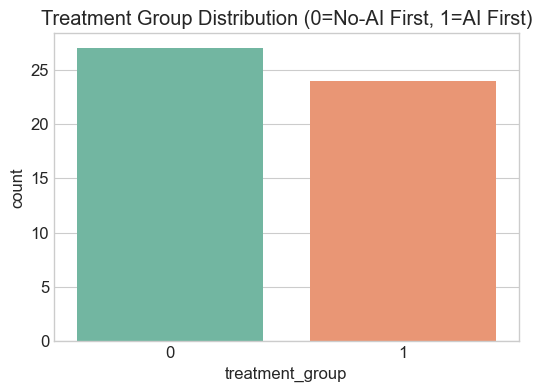

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_part, x='treatment_group', palette='Set2')
plt.title('Treatment Group Distribution (0=No-AI First, 1=AI First)')
plt.show()